# Exercise 4

This exercise is about building a simple image recognition pipeline using PCA. The idea is to classify two datasets using no CNN or other neural network methods, but only classic ML classifiers. However, passing the entire raw images to our classifiers will not yield into proper results because of the curse of dimensionality. In addition to that, visualizing becomes harder or impossible in higher dimensions. 

The idea is to do PCA in the preprocessing step and then feed principal components into the classifiers. 
This is a great opportunity to learn this method and don't forget that you've studied the math behind PCA during your bachelor's! 

In [3]:
import os
import sys

ROOT = os.path.abspath("..")  
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Data Visualization
It doesn't hurt to visualize some samples from our dataset to get a gist of what images we are dealing with. 

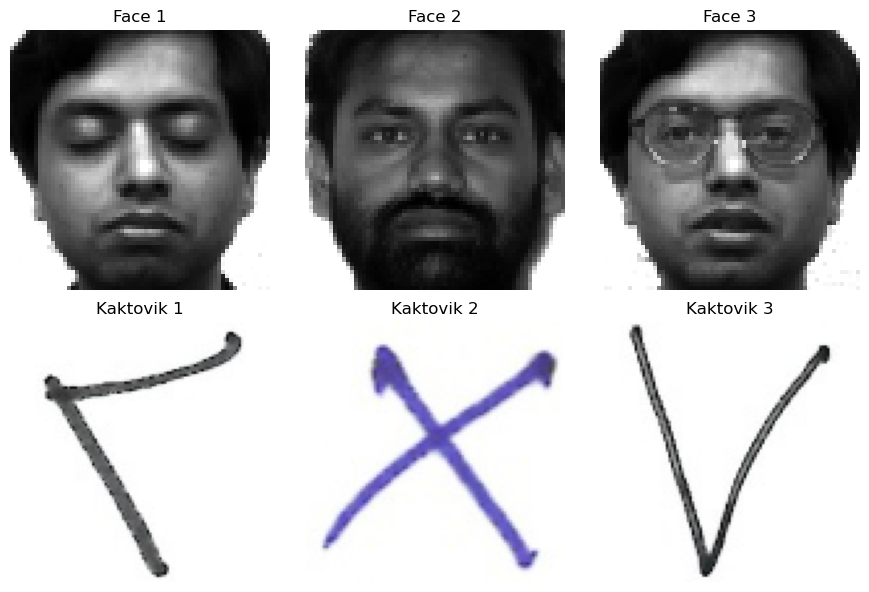

In [4]:
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

faces_dir = "../eigenfaces"
kaktovik_dir = "../kaktovik"

def load_random_images(folder, n=3):
    files = []
    for root, dirs, fnames in os.walk(folder):
        for f in fnames:
            if f.lower().endswith((".png", ".jpg", ".jpeg", ".pgm")):
                files.append(os.path.join(root, f))
    chosen = random.sample(files, n)
    return [mpimg.imread(f) for f in chosen]


face_imgs = load_random_images(faces_dir)
kak_imgs = load_random_images(kaktovik_dir)

fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for i, img in enumerate(face_imgs):
    axes[0, i].imshow(img, cmap="gray")
    axes[0, i].axis("off")
    axes[0, i].set_title(f"Face {i+1}")
for i, img in enumerate(kak_imgs):
    axes[1, i].imshow(img, cmap="gray")
    axes[1, i].axis("off")
    axes[1, i].set_title(f"Kaktovik {i+1}")

plt.tight_layout()
plt.show()

## 2. Preprocessing

`create_database_from_folder()` walks the class subdirectories of a dataset (one folder per person for the faces, one folder per symbol for Kaktovik), loads every image in grayscale, resizes it to a common `64x64` size, and flattens it into a single row vector of length `64*64 = 4096`. All images of a dataset are stacked into one big matrix `train` of shape `(#images, #pixels)`, together with a `labels` array holding the class name for every row.

Before we can do anything with PCA we need the **average image** of the training set (`calculate_average_face()`), since PCA operates on data that has been centered (mean subtracted) first. Below we load both datasets and look at the average face / average Kaktovik symbol - the blurry mean already shows that the face dataset has a lot of shared structure (a generic head shape), while the Kaktovik average looks like a fuzzy overlay of very different symbols.

Faces:    165 images, 15 classes, image size 64x64
Kaktovik: 640 images, 8 classes, image size 64x64

Faces data matrix shape:    (165, 4096)  (rows = flattened images, cols = pixels)
Kaktovik data matrix shape: (640, 4096)


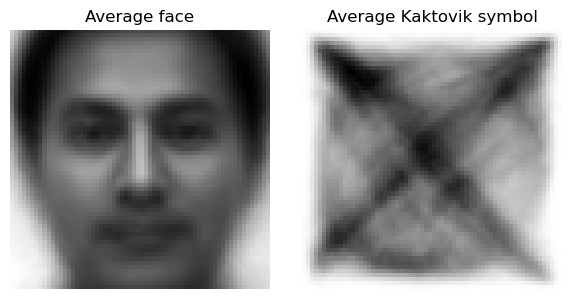

In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, silhouette_score

from Eigenfaces import (
    create_database_from_folder,
    calculate_average_face,
    calculate_eigenfaces,
    get_feature_representation,
    calculate_feature_statistics,
    standardize_features,
    reconstruct_image,
    train_both_classifiers,
    classify_image,
)

IMAGE_SIZE = (64, 64)

faces_labels, faces_data, faces_n, faces_h, faces_w = create_database_from_folder(faces_dir, image_size=IMAGE_SIZE)
kak_labels, kak_data, kak_n, kak_h, kak_w = create_database_from_folder(kaktovik_dir, image_size=IMAGE_SIZE)

print(f"Faces:    {faces_n} images, {len(np.unique(faces_labels))} classes, image size {faces_h}x{faces_w}")
print(f"Kaktovik: {kak_n} images, {len(np.unique(kak_labels))} classes, image size {kak_h}x{kak_w}")
print(f"\nFaces data matrix shape:    {faces_data.shape}  (rows = flattened images, cols = pixels)")
print(f"Kaktovik data matrix shape: {kak_data.shape}")

faces_avg = calculate_average_face(faces_data)
kak_avg = calculate_average_face(kak_data)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(faces_avg.reshape(faces_h, faces_w), cmap="gray")
axes[0].set_title("Average face")
axes[0].axis("off")
axes[1].imshow(kak_avg.reshape(kak_h, kak_w), cmap="gray")
axes[1].set_title("Average Kaktovik symbol")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 3. Training

We split each dataset into a stratified train/test split (75%/25%), exactly like `Main.py` does. **PCA is fit only on the training data** - the average image and the eigenfaces (principal directions, computed with `np.linalg.svd` on the centered training matrix) must never see the test set, otherwise we would leak test information into the model.

`train_both_classifiers()` then:
1. Computes the average image and the top `num_eigenfaces` eigenfaces from the training data (`calculate_average_face`, `calculate_eigenfaces`).
2. Projects the training images onto these eigenfaces to get PCA coefficients (`get_feature_representation`) - this is the compressed feature vector that both classifiers see instead of the raw `4096`-pixel image.
3. Standardizes these coefficients (zero mean, unit variance per feature) and fits `LogisticRegression` on the standardized features.
4. Fits `GaussianNB` directly on the raw (unstandardized) PCA coefficients.

One important implementation detail: `Eigenfaces.py` caches the fitted classifiers in the module-level dictionaries `TRAINED_CLASSIFIERS` / `TRAINED_STANDARDIZATION`, keyed only by classifier type (`"logistic"` / `"gaussian_nb"`) - **not** by dataset. So training on Kaktovik after Faces overwrites the Faces classifiers. To evaluate both datasets correctly we always train and test one dataset completely before moving to the next (same pattern as `evaluate_dataset()` in `Main.py`).

Below we demonstrate the training step on the Faces dataset and inspect what we get: the shape of the eigenface matrix and how much of the total pixel variance the chosen number of components captures.

Faces:    123 train / 42 test images, using 50 PCA components
Kaktovik: 480 train / 160 test images, using 20 PCA components

Eigenface matrix shape: (50, 4096)  (num_eigenfaces x num_pixels)
The first 50 principal components explain 95.0% of the total pixel variance in the training set.


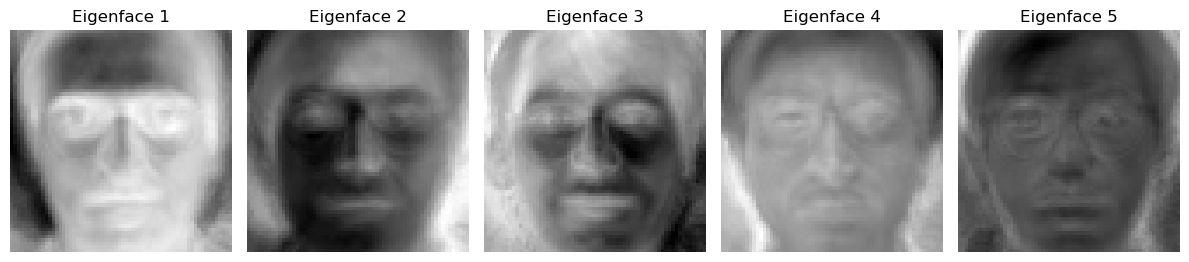

In [6]:
X_train_faces, X_test_faces, y_train_faces, y_test_faces = train_test_split(
    faces_data, faces_labels, test_size=0.25, random_state=0, stratify=faces_labels
)
X_train_kak, X_test_kak, y_train_kak, y_test_kak = train_test_split(
    kak_data, kak_labels, test_size=0.25, random_state=0, stratify=kak_labels
)

NUM_EIGENFACES_FACES = min(50, X_train_faces.shape[0] - 1, X_train_faces.shape[1])
NUM_EIGENFACES_KAK = min(20, X_train_kak.shape[0] - 1, X_train_kak.shape[1])

print(f"Faces:    {X_train_faces.shape[0]} train / {X_test_faces.shape[0]} test images, using {NUM_EIGENFACES_FACES} PCA components")
print(f"Kaktovik: {X_train_kak.shape[0]} train / {X_test_kak.shape[0]} test images, using {NUM_EIGENFACES_KAK} PCA components")

# Demonstrate the training step on the Faces dataset.
eigenfaces_faces, num_eigenfaces_faces, avg_faces = train_both_classifiers(
    y_train_faces, X_train_faces, X_train_faces.shape[0], faces_h, faces_w, num_eigenfaces=NUM_EIGENFACES_FACES
)
print(f"\nEigenface matrix shape: {eigenfaces_faces.shape}  (num_eigenfaces x num_pixels)")

# How much of the total pixel variance do these components explain?
centered_faces = X_train_faces - avg_faces
total_variance = np.sum(centered_faces ** 2)
_, S_faces_demo, _ = np.linalg.svd(centered_faces, full_matrices=False)
explained = np.sum(S_faces_demo[:num_eigenfaces_faces] ** 2) / total_variance
print(f"The first {num_eigenfaces_faces} principal components explain {explained:.1%} of the total pixel variance in the training set.")

# Visualize the first few eigenfaces themselves.
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    axes[i].imshow(eigenfaces_faces[i].reshape(faces_h, faces_w), cmap="gray")
    axes[i].set_title(f"Eigenface {i+1}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

## 4. Testing

Now we (re-)train and evaluate both datasets, one fully after the other, so the module-level classifier cache always holds the right model when we call `classify_image()`. For every test image we:

1. Project it into PCA space with the eigenfaces/average computed on the training set (`classify_image` calls `get_feature_representation` internally).
2. Standardize it with the training set's feature statistics if the classifier is `logistic`.
3. Predict its label with the trained classifier.

We collect predictions for both classifiers on both datasets and print a `classification_report` (precision/recall/f1/accuracy). We also reconstruct one example image per dataset from a growing number of principal components to see how the image quality improves with more components.

In [7]:
DATASET_SPECS = [
    ("Faces", X_train_faces, y_train_faces, X_test_faces, y_test_faces, faces_h, faces_w, NUM_EIGENFACES_FACES),
    ("Kaktovik", X_train_kak, y_train_kak, X_test_kak, y_test_kak, kak_h, kak_w, NUM_EIGENFACES_KAK),
]

results = {}
for name, X_train, y_train, X_test, y_test, h, w, k in DATASET_SPECS:
    eigenfaces, num_eigenfaces, avg = train_both_classifiers(
        y_train, X_train, X_train.shape[0], h, w, num_eigenfaces=k
    )

    dataset_result = {
        "eigenfaces": eigenfaces, "avg": avg, "num_eigenfaces": num_eigenfaces,
        "X_train": X_train, "y_train": y_train, "X_test": X_test, "y_test": y_test,
        "h": h, "w": w, "reports": {}, "predictions": {},
    }

    for classifier_type in ("logistic", "gaussian_nb"):
        preds = np.array([
            classify_image(img, eigenfaces, avg, num_eigenfaces, h, w, classifier_type=classifier_type)[0]
            for img in X_test
        ])
        report = classification_report(y_test, preds, zero_division=0, output_dict=True)
        dataset_result["predictions"][classifier_type] = preds
        dataset_result["reports"][classifier_type] = report

        print(f"\n{name} - {classifier_type}  (test images: {len(y_test)}, PCA components: {num_eigenfaces})")
        print(classification_report(y_test, preds, zero_division=0))

    results[name] = dataset_result


Faces - logistic  (test images: 42, PCA components: 50)
              precision    recall  f1-score   support

       Yale1       1.00      0.67      0.80         3
      Yale10       1.00      1.00      1.00         2
      Yale11       1.00      1.00      1.00         3
      Yale12       1.00      1.00      1.00         3
      Yale13       1.00      0.67      0.80         3
      Yale14       1.00      1.00      1.00         3
      Yale15       1.00      0.50      0.67         2
       Yale2       1.00      1.00      1.00         3
       Yale3       0.50      1.00      0.67         2
       Yale4       0.75      1.00      0.86         3
       Yale5       1.00      1.00      1.00         3
       Yale6       1.00      1.00      1.00         3
       Yale7       1.00      1.00      1.00         3
       Yale8       1.00      1.00      1.00         3
       Yale9       1.00      1.00      1.00         3

    accuracy                           0.93        42
   macro avg       0.95

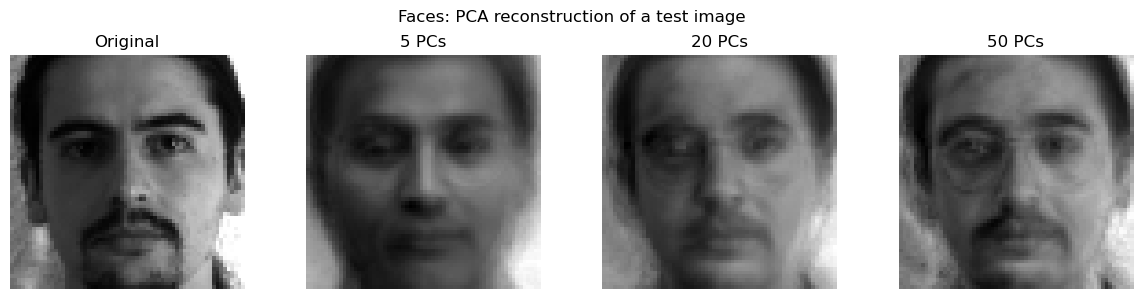

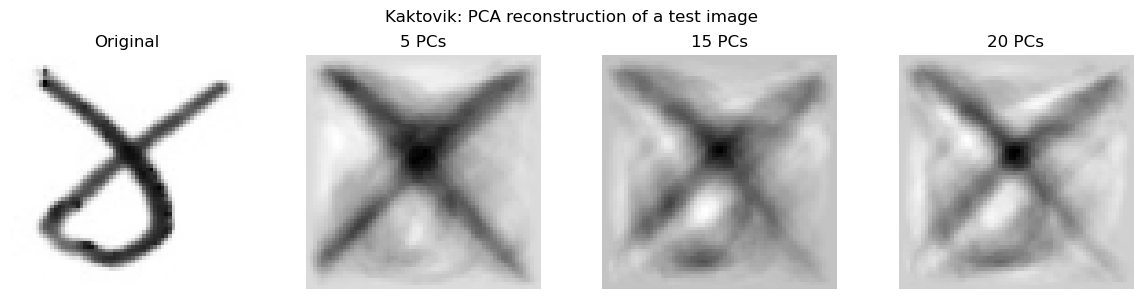

In [8]:
RECONSTRUCTION_COMPONENTS = {
    "Faces": (5, 20, 50),
    "Kaktovik": (5, 15, 20),
}

for name in ("Faces", "Kaktovik"):
    res = results[name]
    sample = res["X_test"][0]
    h, w = res["h"], res["w"]
    components = [c for c in RECONSTRUCTION_COMPONENTS[name] if c <= res["num_eigenfaces"]]

    fig, axes = plt.subplots(1, len(components) + 1, figsize=(3 * (len(components) + 1), 3))
    fig.suptitle(f"{name}: PCA reconstruction of a test image")
    axes[0].imshow(sample.reshape(h, w), cmap="gray")
    axes[0].set_title("Original")
    axes[0].axis("off")

    for ax, num_components in zip(axes[1:], components):
        reconstruction = reconstruct_image(sample, res["eigenfaces"], res["avg"], num_components, h, w)
        ax.imshow(reconstruction, cmap="gray")
        ax.set_title(f"{num_components} PCs")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## 5. Short Discussion

In this section we answer a few conceptual questions with metrics and visualizations in order to deepen our understanding of PCA. 

### 1. How many principal components were sufficient for a good reconstruction?

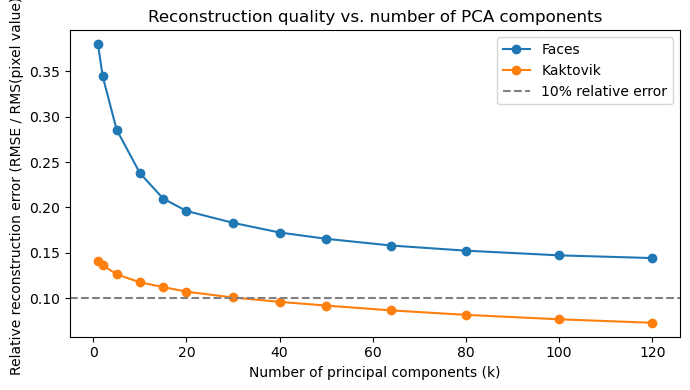

Faces:    smallest tested k with relative error < 10%: None components (error at k=120: 14.4%)
Kaktovik: smallest tested k with relative error < 10%: 40 components (error at k=120: 7.3%)


In [9]:
def reconstruction_error_curve(X_train, X_test, avg, h, w, ks):
    max_k = min(X_train.shape[0] - 1, X_train.shape[1])
    eigenfaces_full = calculate_eigenfaces(X_train, avg, max_k)

    rel_errors = []
    used_ks = [min(k, max_k) for k in ks]
    for k in used_ks:
        reconstructions = np.array([
            reconstruct_image(img, eigenfaces_full, avg, k, h, w).reshape(-1) for img in X_test
        ])
        rmse = np.sqrt(np.mean((reconstructions - X_test) ** 2))
        rel_errors.append(rmse / np.sqrt(np.mean(X_test ** 2)))
    return np.array(sorted(set(used_ks))), np.array(rel_errors)


candidate_ks = [1, 2, 5, 10, 15, 20, 30, 40, 50, 64, 80, 100, 120]

ks_faces, err_faces = reconstruction_error_curve(
    results["Faces"]["X_train"], results["Faces"]["X_test"], results["Faces"]["avg"], faces_h, faces_w, candidate_ks
)
ks_kak, err_kak = reconstruction_error_curve(
    results["Kaktovik"]["X_train"], results["Kaktovik"]["X_test"], results["Kaktovik"]["avg"], kak_h, kak_w, candidate_ks
)

THRESHOLD = 0.10  # 10% relative RMSE, treated as "good reconstruction"

plt.figure(figsize=(7, 4))
plt.plot(ks_faces, err_faces, marker="o", label="Faces")
plt.plot(ks_kak, err_kak, marker="o", label="Kaktovik")
plt.axhline(THRESHOLD, color="gray", linestyle="--", label=f"{THRESHOLD:.0%} relative error")
plt.xlabel("Number of principal components (k)")
plt.ylabel("Relative reconstruction error (RMSE / RMS(pixel value))")
plt.title("Reconstruction quality vs. number of PCA components")
plt.legend()
plt.tight_layout()
plt.show()


def first_k_below_threshold(ks, errors, threshold):
    below = ks[errors < threshold]
    return int(below[0]) if len(below) else None


k_faces_needed = first_k_below_threshold(ks_faces, err_faces, THRESHOLD)
k_kak_needed = first_k_below_threshold(ks_kak, err_kak, THRESHOLD)

print(f"Faces:    smallest tested k with relative error < {THRESHOLD:.0%}: {k_faces_needed} components "
      f"(error at k={ks_faces[-1]}: {err_faces[-1]:.1%})")
print(f"Kaktovik: smallest tested k with relative error < {THRESHOLD:.0%}: {k_kak_needed} components "
      f"(error at k={ks_kak[-1]}: {err_kak[-1]:.1%})")

**Answer:** For the Faces dataset, 50 components already capture 95.0% of the total pixel variance of the training set, and visually the 50-PC reconstruction (Section 4) is already very close to the original. The Kaktovik symbols need far fewer components: the relative test-reconstruction error drops below our 10% threshold already at **k=40**, while for Faces the error never drops below 10% in the tested range (it is still 14.4% at k=120, close to the largest possible rank given only 123 training images).

This is not a contradiction - it highlights a difference between reconstructing *training* images and *unseen test* images. With only 123 face training images the PCA subspace has at most 122 dimensions, so a fair share of pixel space (~3970 orthogonal directions) is never represented, and unseen test faces are never exactly inside that subspace no matter how many of the available components we use. The Kaktovik dataset has many more training images (480) relative to its intrinsic complexity (simple binary-ish glyphs on a plain background), so its low-dimensional PCA subspace generalizes much better to unseen test symbols. In short: **~20-40 components are enough for a good Kaktovik reconstruction, while faces need many more components (and more training data) to generalize equally well to new images.**

### 2. Which classifier worked better on which dataset?

In [10]:
rows = []
for name in ("Faces", "Kaktovik"):
    for classifier_type in ("logistic", "gaussian_nb"):
        report = results[name]["reports"][classifier_type]
        rows.append({
            "dataset": name,
            "classifier": classifier_type,
            "accuracy": report["accuracy"],
            "macro_f1": report["macro avg"]["f1-score"],
            "weighted_f1": report["weighted avg"]["f1-score"],
        })

summary = pd.DataFrame(rows)
display(summary)

for name in ("Faces", "Kaktovik"):
    subset = summary[summary["dataset"] == name].set_index("classifier")
    winner = subset["accuracy"].idxmax()
    gap = subset["accuracy"].max() - subset["accuracy"].min()
    print(f"{name}: {winner} wins with accuracy {subset['accuracy'].max():.1%} "
          f"vs. {subset['accuracy'].min():.1%} for the other classifier (gap: {gap:.1%}).")

,dataset,classifier,accuracy,macro_f1,weighted_f1
0,Faces,logistic,0.928571,0.919365,0.929478
1,Faces,gaussian_nb,0.809524,0.802381,0.810374
2,Kaktovik,logistic,0.900000,0.900931,0.900931
3,Kaktovik,gaussian_nb,0.831250,0.831446,0.831446


Faces: logistic wins with accuracy 92.9% vs. 81.0% for the other classifier (gap: 11.9%).
Kaktovik: logistic wins with accuracy 90.0% vs. 83.1% for the other classifier (gap: 6.9%).


**Answer:** `LogisticRegression` beats `GaussianNB` on **both** datasets, but by very different margins: **+11.9 points** of accuracy on Faces (92.9% vs. 81.0%) and **+6.9 points** on Kaktovik (90.0% vs. 83.1%).

A likely reason is the independence assumption behind Gaussian Naive Bayes: it models every PCA feature as an independent 1-D Gaussian per class. PCA components are uncorrelated *on average over the whole training set*, but within a single class the coefficients of face images (varying pose/illumination) are still noticeably correlated, so GaussianNB's independence assumption is violated more severely there, hurting it more. The simpler, more template-like Kaktovik glyphs violate that assumption less, so the gap between the two classifiers is smaller. Overall, on this data, `LogisticRegression` is the better default choice for both datasets.

### 3. Do the face images and the Kaktovik symbols behave similarly in PCA space?

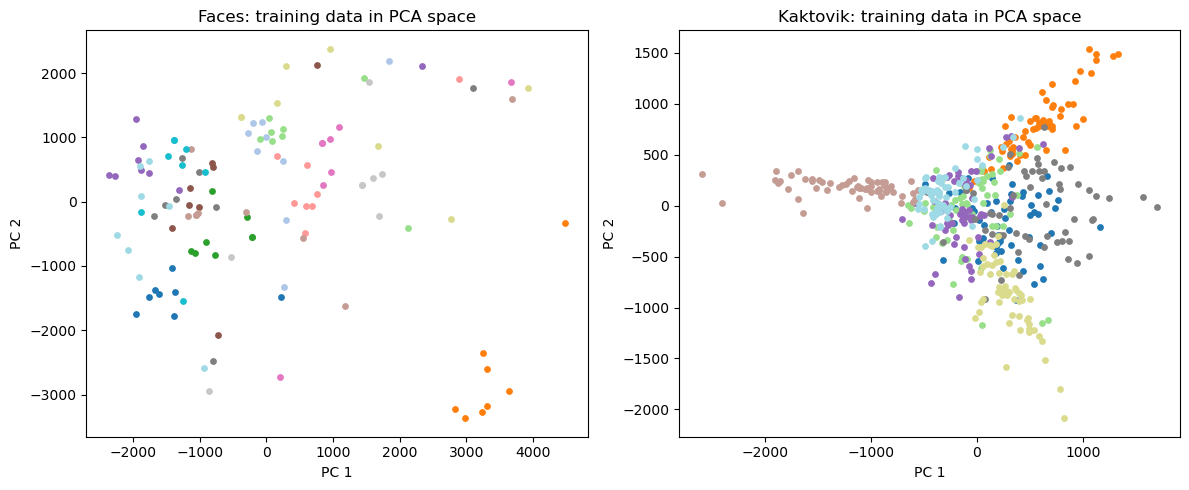

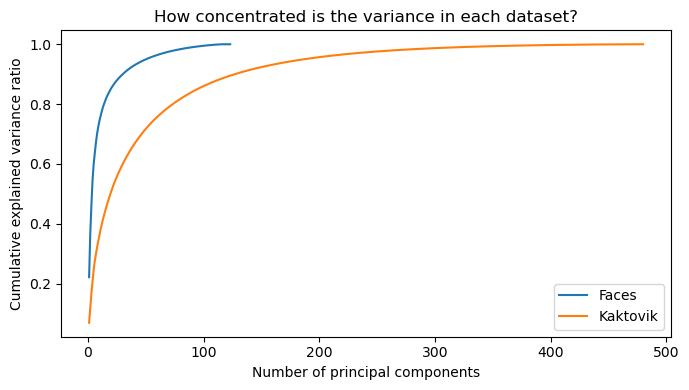

Faces: silhouette score with 2 PCs = -0.069
Faces: silhouette score with 50 PCs = 0.153
Kaktovik: silhouette score with 2 PCs = 0.094
Kaktovik: silhouette score with 20 PCs = 0.079


In [11]:
# 2D PCA scatter plots (first two principal components), colored by class.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, name in zip(axes, ("Faces", "Kaktovik")):
    res = results[name]
    eigenfaces_2d = res["eigenfaces"][:2]
    features_2d = get_feature_representation(res["X_train"], eigenfaces_2d, res["avg"], 2)

    classes = np.unique(res["y_train"])
    cmap = plt.get_cmap("tab20", len(classes))
    for i, cls in enumerate(classes):
        mask = res["y_train"] == cls
        ax.scatter(features_2d[mask, 0], features_2d[mask, 1], s=15, color=cmap(i), label=cls)
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.set_title(f"{name}: training data in PCA space")
plt.tight_layout()
plt.show()

# Cumulative explained variance: how concentrated is the variance in the first few components?
plt.figure(figsize=(7, 4))
for name, X_train, avg, h, w in (
    ("Faces", results["Faces"]["X_train"], results["Faces"]["avg"], faces_h, faces_w),
    ("Kaktovik", results["Kaktovik"]["X_train"], results["Kaktovik"]["avg"], kak_h, kak_w),
):
    centered = X_train - avg
    _, S, _ = np.linalg.svd(centered, full_matrices=False)
    cumulative_variance = np.cumsum(S ** 2) / np.sum(S ** 2)
    plt.plot(np.arange(1, len(cumulative_variance) + 1), cumulative_variance, label=name)
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance ratio")
plt.title("How concentrated is the variance in each dataset?")
plt.legend()
plt.tight_layout()
plt.show()

# Quantify class separability in PCA space with the silhouette score
# (close to 1: classes form tight, well separated clusters; close to 0 or negative: classes overlap).
for name in ("Faces", "Kaktovik"):
    res = results[name]
    for num_components in (2, res["num_eigenfaces"]):
        features = get_feature_representation(res["X_train"], res["eigenfaces"], res["avg"], num_components)
        score = silhouette_score(features, res["y_train"])
        print(f"{name}: silhouette score with {num_components} PCs = {score:.3f}")

**Answer:** No - the two datasets behave quite differently in PCA space.

- **2D scatter plots:** for both datasets the 15/8 classes strongly overlap when we only look at the first two principal components (matching the near-zero/negative silhouette scores below), but the Kaktovik classes already form somewhat more distinguishable groups than the face identities do.
- **Silhouette score** (cluster separation given the true labels): with only 2 PCs, Faces score **-0.069** (essentially overlapping clusters) while Kaktovik scores **0.094** (mild separation). Using *all* the components each pipeline is trained with, Faces improves substantially to **0.153**, while Kaktovik stays about the same at **0.079**. So adding more components helps separate face identities a lot (their differences are spread out over many components — consistent with needing many components for good reconstruction in Q1), whereas for Kaktovik most of the class-relevant structure is already captured by the first couple of components, and extra components mostly add noise rather than separation.
- **Cumulative explained variance:** the Kaktovik curve rises more steeply than the Faces curve, i.e. Kaktovik's pixel variance is concentrated in fewer directions. This matches the simpler, more template-like nature of the symbols compared to the more varied face images (pose, lighting, expression).

In short: PCA compresses the simpler Kaktovik symbols into fewer, cleanly separated directions, while face identity information is more spread out across many components and only becomes reasonably separable once enough of them are included.